In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import gc
sns.set_theme()
gc.enable()

In [2]:
main_data=pd.read_csv('application_train.csv')
main_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
numerical_features=main_data.select_dtypes(exclude='object').columns
encoded_features=pd.Index(['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                           'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
                           'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
                           'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
                           'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
                           'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
                           'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
                           'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
                           'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
                           'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
                           'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
                           'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'])
categorical_features=main_data.columns.difference(numerical_features)
numerical_features=numerical_features.difference(encoded_features)

# Numerical Features

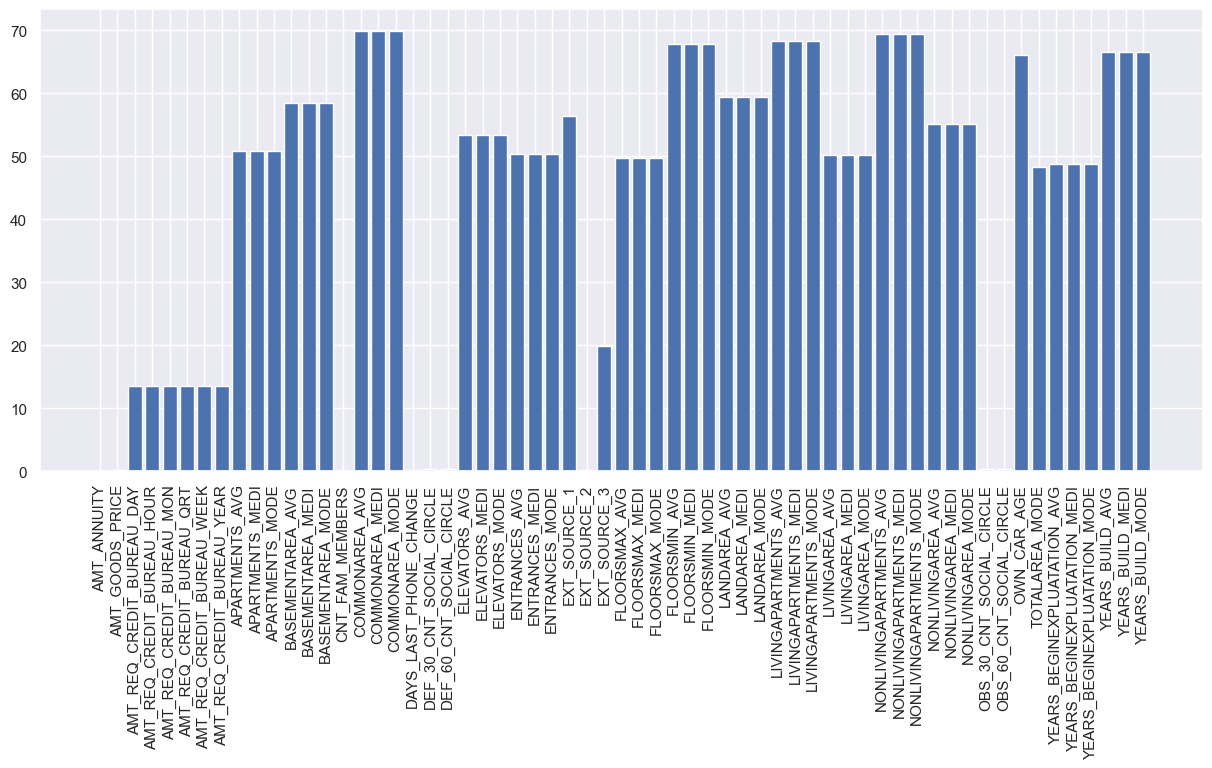

In [4]:
numerical_frame=main_data.loc[:, numerical_features]
plot_data=numerical_frame.isnull().sum()*100/numerical_frame.shape[0]
plot_data=plot_data[plot_data>0]
ax=plt.axes()
ax.bar(plot_data.index, plot_data.values)
ax.tick_params(axis='x', rotation=90)
ax.get_figure().set_size_inches(15, 6)

### Functions

In [5]:
def plot_hist_box(data, feature):
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [6]:
def plot_hist_default_pct(feature, dataframe, bins):
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [7]:
def calc_iqr(feature, data):
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [8]:
def plot_kde_vs_target(feature, main_data=main_data):
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [9]:
def plot_all_numeric_kde():
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [10]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [11]:
def median_vs_target(feature, data):
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [12]:
# plot_all_numeric_kde()

### Important Numerical

In [13]:
important_kde=pd.Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH',
                        'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
                        'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
                        'EXT_SOURCE_3'])
numerical_frame=numerical_frame[important_kde]
numerical_frame['TARGET']=main_data['TARGET']

In [14]:
numerical_frame.isnull().sum()

AMT_ANNUITY                   12
AMT_CREDIT                     0
AMT_INCOME_TOTAL               0
AMT_GOODS_PRICE              278
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_ID_PUBLISH                0
DAYS_REGISTRATION              0
DAYS_LAST_PHONE_CHANGE         1
EXT_SOURCE_1              173378
EXT_SOURCE_2                 660
EXT_SOURCE_3               60965
TARGET                         0
dtype: int64

## AMT_CREDIT

In [15]:
numerical_frame['AMT_CREDIT'].isnull().sum()

0

In [16]:
numerical_frame['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

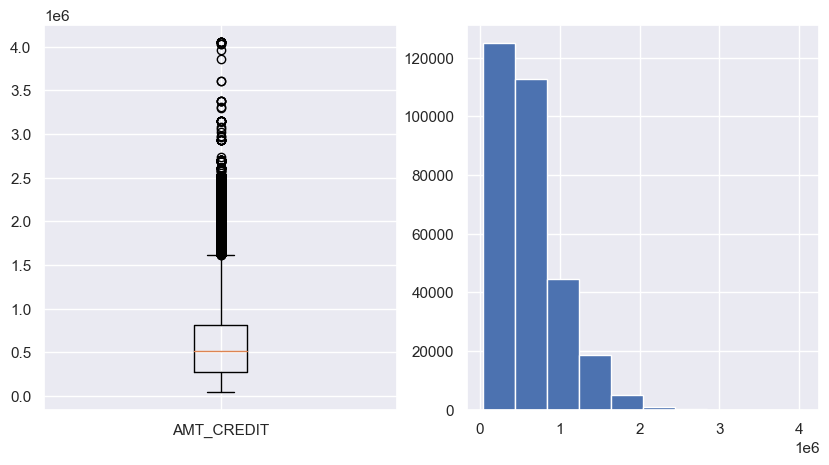

In [17]:
plot_hist_box(numerical_frame, 'AMT_CREDIT');

#### Marking outliers with a flag column

Number of outliers : 43


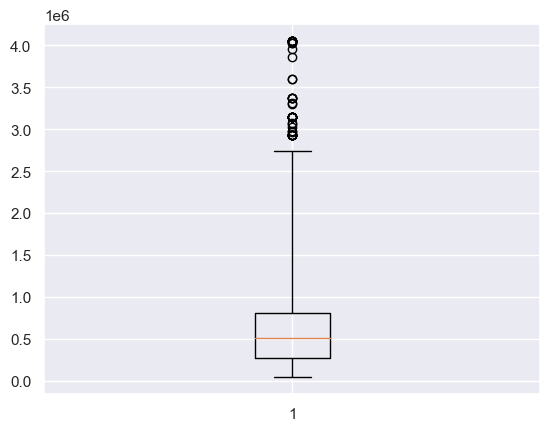

In [18]:
plt.boxplot(numerical_frame['AMT_CREDIT'], whis=3.7);
q1, q3, iqr=calc_iqr('AMT_CREDIT', numerical_frame)
numerical_frame['AMT_CREDIT_outlier']=0
numerical_frame.loc[numerical_frame['AMT_CREDIT']>q3+3.7*iqr, 'AMT_CREDIT_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_CREDIT_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_CREDIT_outlier']==1).sum()))

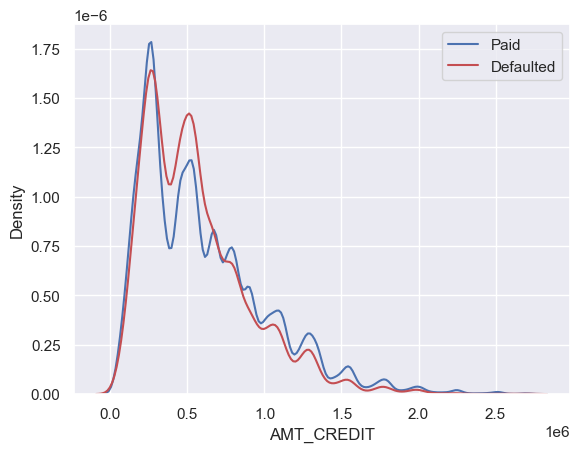

In [19]:
plot_kde_vs_target('AMT_CREDIT', good_frame)

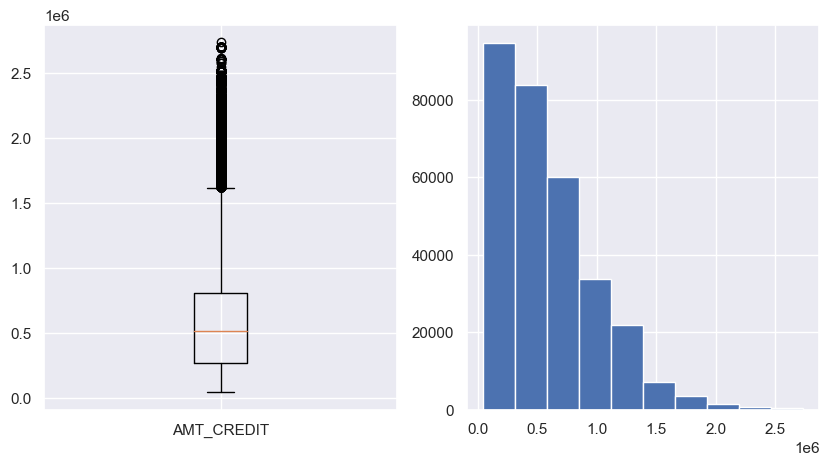

In [20]:
plot_hist_box(good_frame, 'AMT_CREDIT');

(44999.999, 188460.0]      6.801111
(188460.0, 267102.0]       7.680379
(267102.0, 337500.0]       8.723693
(337500.0, 454500.0]      10.305344
(454500.0, 545040.0]      10.153233
(545040.0, 679500.0]       9.081739
(679500.0, 855000.0]       7.741548
(855000.0, 1125000.0]      6.752499
(1125000.0, 2736000.0]     5.305149
Name: AMT_CREDIT_binned, dtype: float64


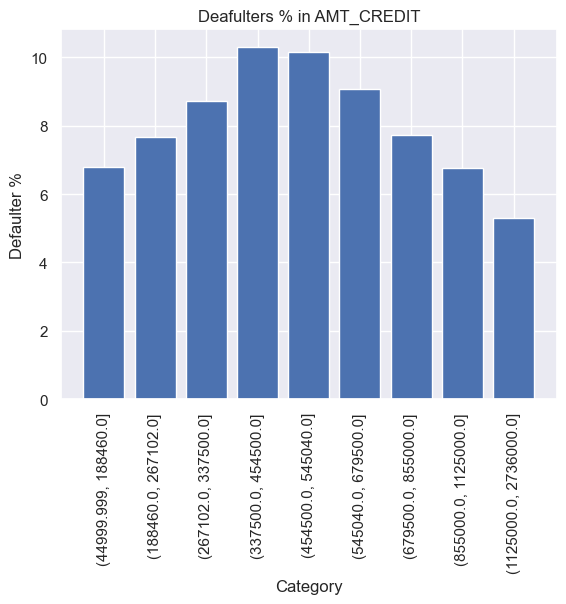

In [21]:
plot_hist_default_pct('AMT_CREDIT', good_frame, 9)

## AMT_INCOME_TOTAL

In [22]:
numerical_frame['AMT_INCOME_TOTAL'].isnull().sum()

0

In [23]:
numerical_frame['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

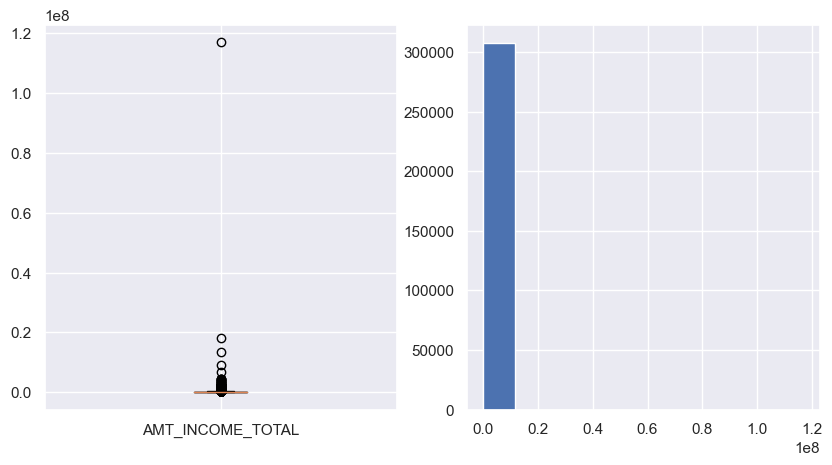

In [24]:
plot_hist_box(numerical_frame, 'AMT_INCOME_TOTAL')

Number of outliers : 576


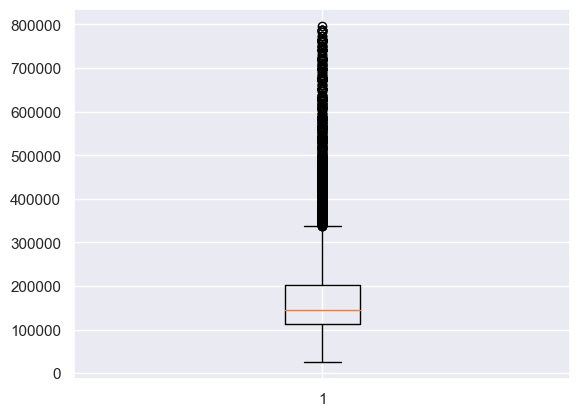

In [41]:
df=numerical_frame.loc[numerical_frame['AMT_INCOME_TOTAL']<0.8e6, :]
plt.boxplot(df['AMT_INCOME_TOTAL']);
numerical_frame['AMT_INCOME_TOTAL_outlier']=0
numerical_frame.loc[numerical_frame['AMT_INCOME_TOTAL']>=0.8e6, 'AMT_INCOME_TOTAL_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_INCOME_TOTAL_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_INCOME_TOTAL_outlier']==1).sum()))

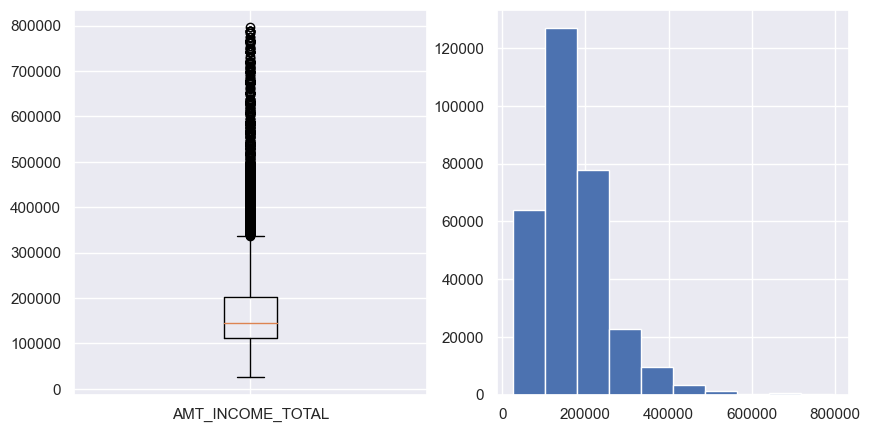

In [42]:
plot_hist_box(good_frame, 'AMT_INCOME_TOTAL');

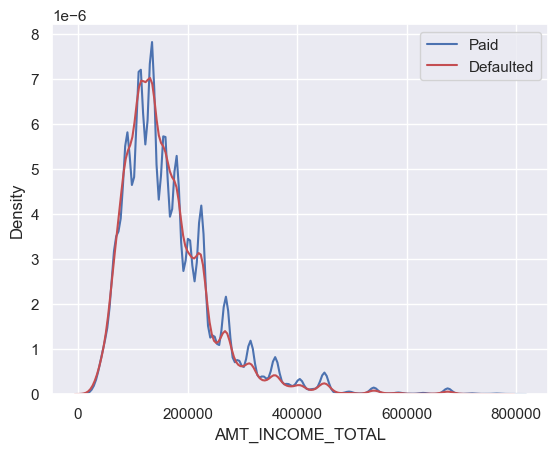

In [43]:
plot_kde_vs_target('AMT_INCOME_TOTAL', good_frame)

In [29]:
plot_hist_default_pct('AMT_INCOME_TOTAL', good_frame, 9)

IndexError: cannot do a non-empty take from an empty axes.

## AMT_ANNUITY

In [25]:
numerical_frame['AMT_ANNUITY'].isnull().sum()

12

In [26]:
numerical_frame['AMT_ANNUITY'].describe()

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

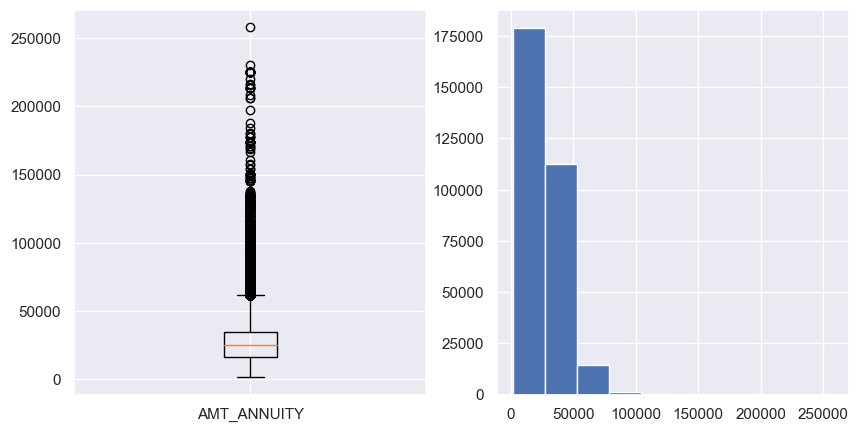

In [27]:
plot_hist_box(numerical_frame, 'AMT_ANNUITY')

Number of outliers : 81


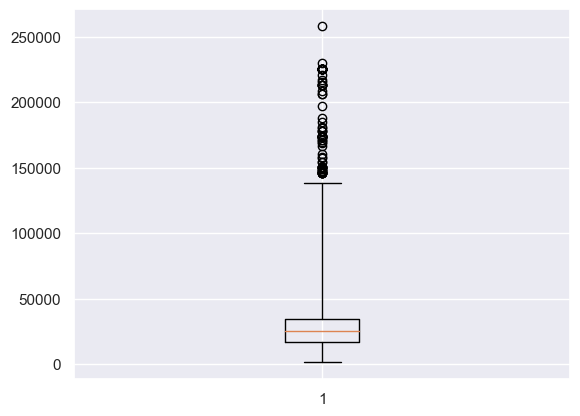

In [44]:
plt.boxplot(numerical_frame['AMT_ANNUITY'].dropna(), whis=6);
q1, q3, iqr=calc_iqr('AMT_ANNUITY', numerical_frame)
numerical_frame['AMT_ANNUITY_outlier']=0
numerical_frame.loc[numerical_frame['AMT_ANNUITY']>q3+6*iqr, 'AMT_ANNUITY_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_ANNUITY_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_ANNUITY_outlier']==1).sum()))

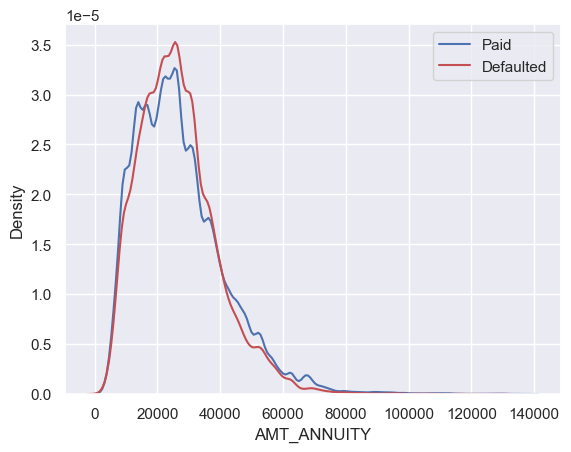

In [45]:
plot_kde_vs_target('AMT_ANNUITY', good_frame)

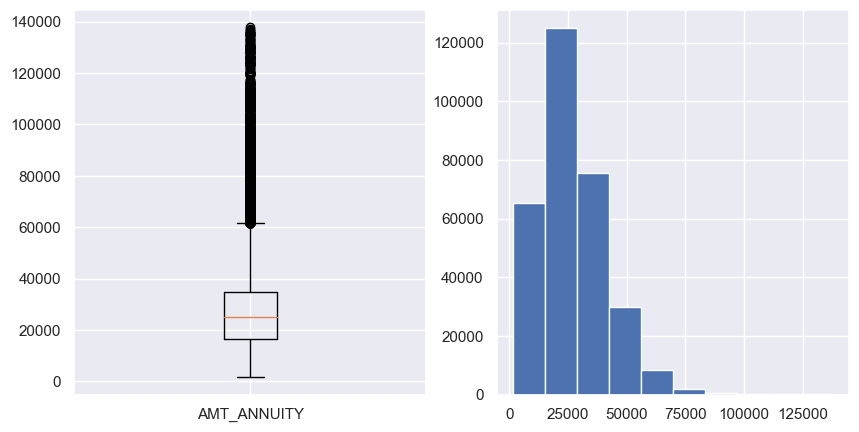

In [46]:
plot_hist_box(good_frame, 'AMT_ANNUITY');

(1615.499, 11502.0]    6.943591
(11502.0, 15705.0]     7.173379
(15705.0, 19548.0]     8.701763
(19548.0, 23107.5]     8.811613
(23107.5, 26473.5]     8.239998
(26473.5, 30717.0]     9.772290
(30717.0, 36229.5]     9.306161
(36229.5, 44775.0]     7.825171
(44775.0, 137844.0]    5.896820
Name: AMT_ANNUITY_binned, dtype: float64


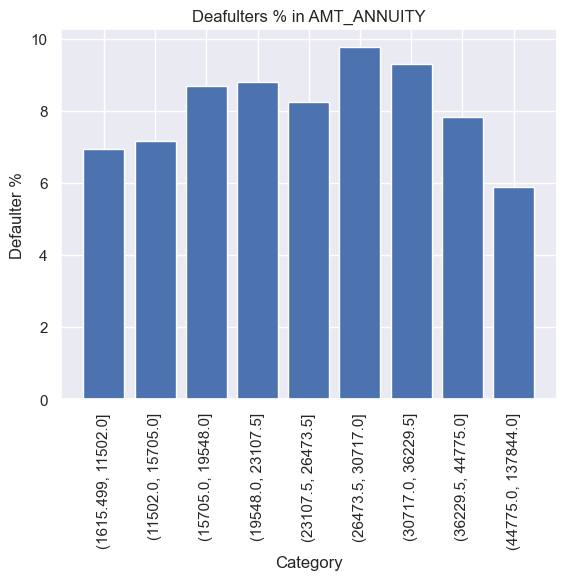

In [113]:
plot_hist_default_pct('AMT_ANNUITY', good_frame, 9)

## AMT_GOODS_PRICE

In [116]:
numerical_frame['AMT_GOODS_PRICE'].isnull().sum()

278

In [117]:
numerical_frame['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

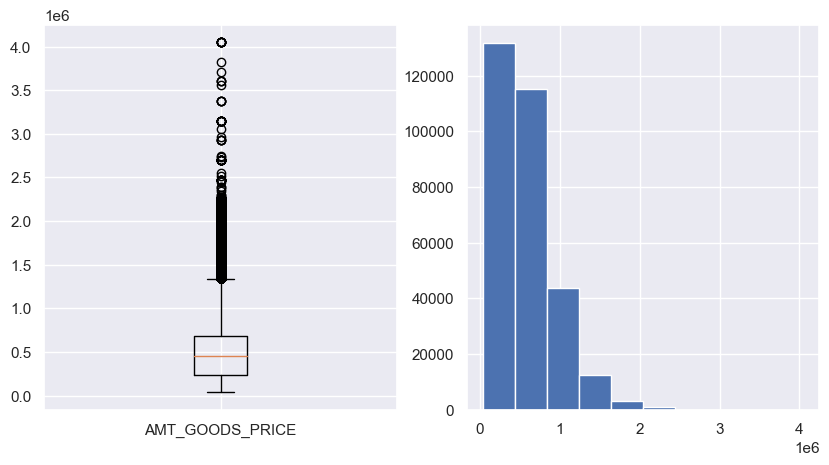

In [118]:
plot_hist_box(numerical_frame, 'AMT_GOODS_PRICE')

Number of outliers : 69


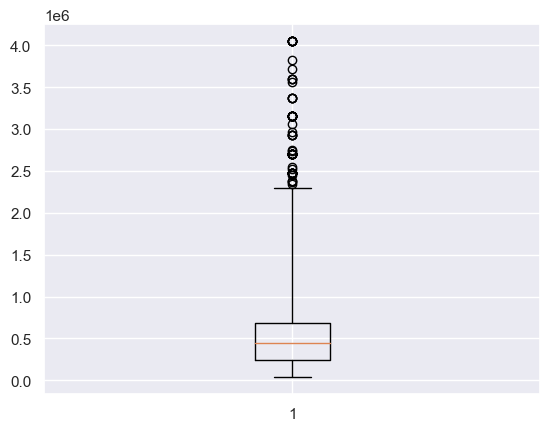

In [53]:
plt.boxplot(numerical_frame['AMT_GOODS_PRICE'].dropna(), whis=3.7);
q1, q3, iqr=calc_iqr('AMT_GOODS_PRICE', numerical_frame)
numerical_frame['AMT_GOODS_PRICE_outlier']=0
numerical_frame.loc[numerical_frame['AMT_GOODS_PRICE']>q3+3.7*iqr, 'AMT_GOODS_PRICE_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_GOODS_PRICE_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_GOODS_PRICE_outlier']==1).sum()))

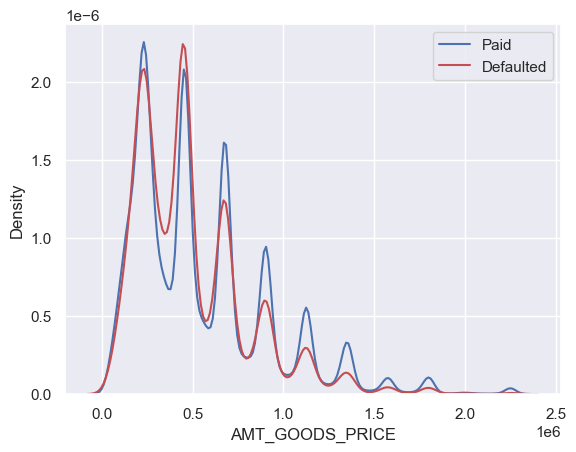

In [54]:
plot_kde_vs_target('AMT_GOODS_PRICE', good_frame)

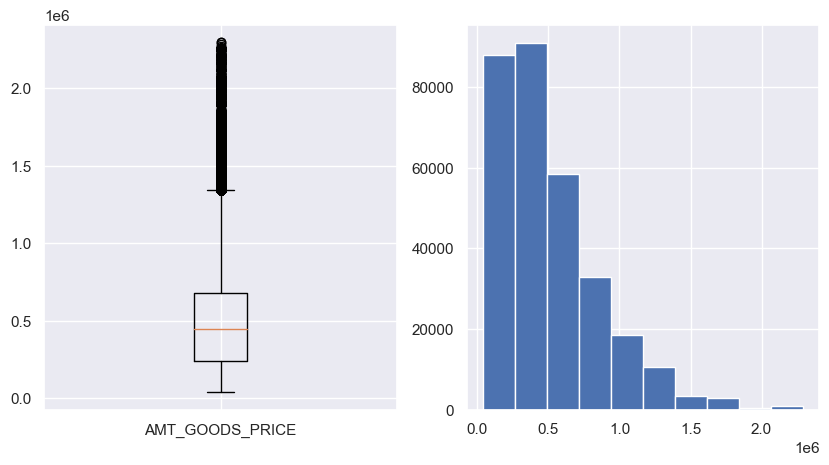

In [55]:
plot_hist_box(good_frame, 'AMT_GOODS_PRICE');

(40499.999, 180000.0]     7.286496
(180000.0, 225000.0]      8.908352
(225000.0, 292500.0]      7.907479
(292500.0, 450000.0]     12.225508
(450000.0, 463500.0]      5.750231
(463500.0, 675000.0]      8.231946
(675000.0, 720000.0]      4.954737
(720000.0, 994500.0]      6.633725
(994500.0, 2295000.0]     5.040441
Name: AMT_GOODS_PRICE_binned, dtype: float64


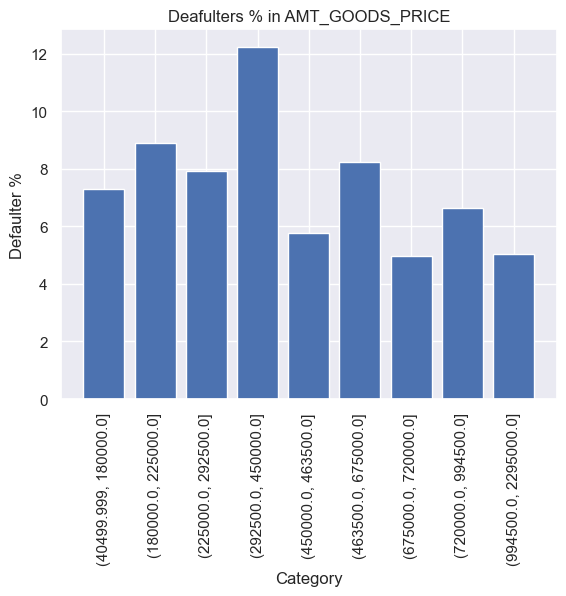

In [56]:
plot_hist_default_pct('AMT_GOODS_PRICE', good_frame, 9)

## DAYS_BIRTH

In [33]:
numerical_frame['DAYS_BIRTH'].isnull().sum()

0

In [34]:
numerical_frame['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

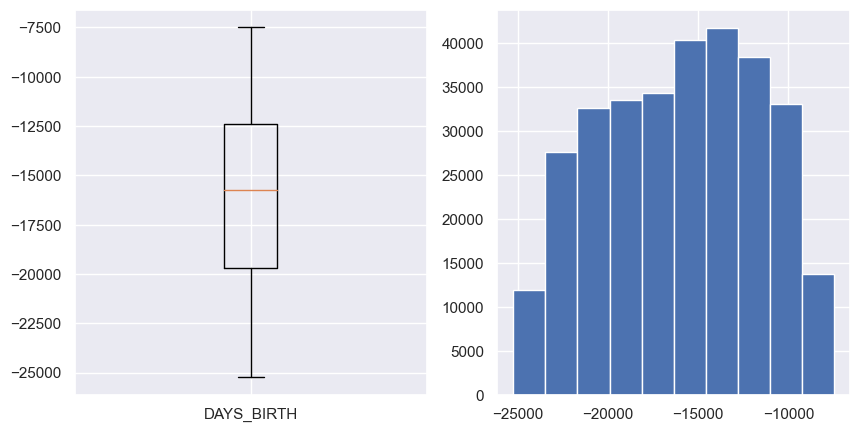

In [35]:
plot_hist_box(numerical_frame, 'DAYS_BIRTH')

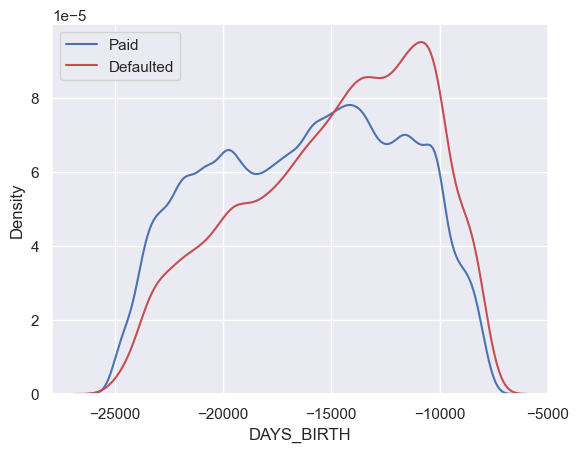

In [36]:
plot_kde_vs_target('DAYS_BIRTH', numerical_frame)

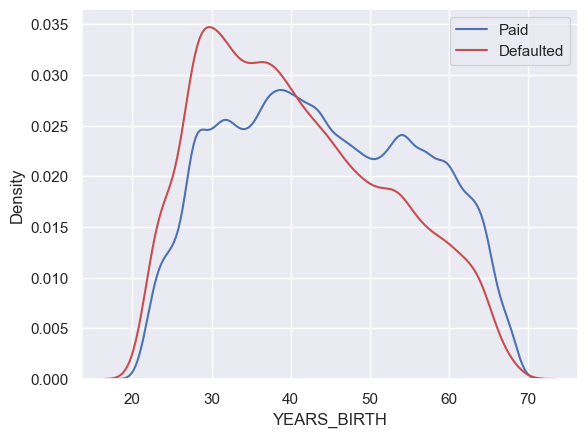

In [37]:
numerical_frame['YEARS_BIRTH']=numerical_frame['DAYS_BIRTH']/-365
plot_kde_vs_target('YEARS_BIRTH', numerical_frame)

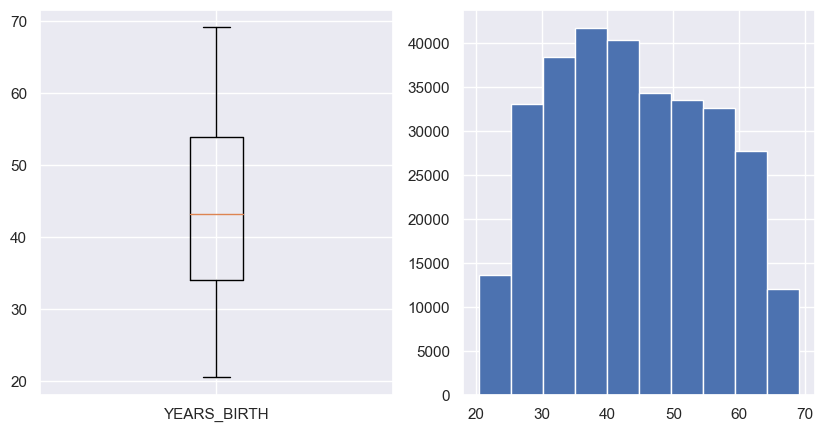

In [38]:
plot_hist_box(numerical_frame, 'YEARS_BIRTH')

(20.517, 28.594]    11.537111
(28.594, 32.899]    10.686487
(32.899, 37.195]     9.724336
(37.195, 41.09]      8.406976
(41.09, 45.31]       7.802664
(45.31, 50.173]      7.422469
(50.173, 55.047]     6.633489
(55.047, 60.225]     5.478971
(60.225, 69.121]     4.961799
Name: YEARS_BIRTH_binned, dtype: float64


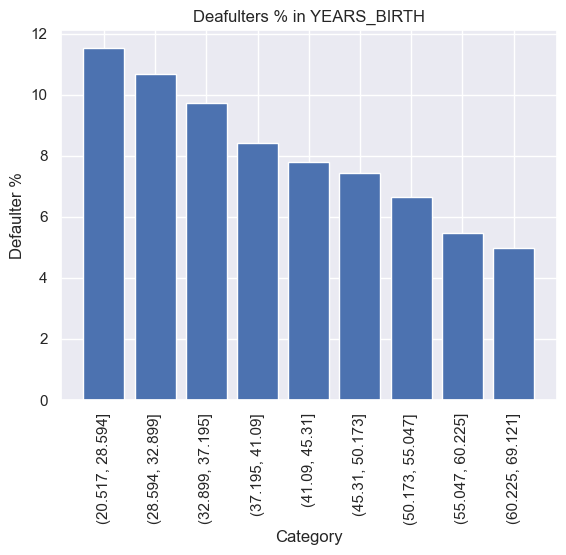

In [39]:
plot_hist_default_pct('YEARS_BIRTH', numerical_frame, 9)

## DAYS_ID_PUBLISH

In [40]:
numerical_frame['DAYS_ID_PUBLISH'].isnull().sum()

0

In [41]:
numerical_frame['DAYS_ID_PUBLISH'].describe()

count    307511.000000
mean      -2994.202373
std        1509.450419
min       -7197.000000
25%       -4299.000000
50%       -3254.000000
75%       -1720.000000
max           0.000000
Name: DAYS_ID_PUBLISH, dtype: float64

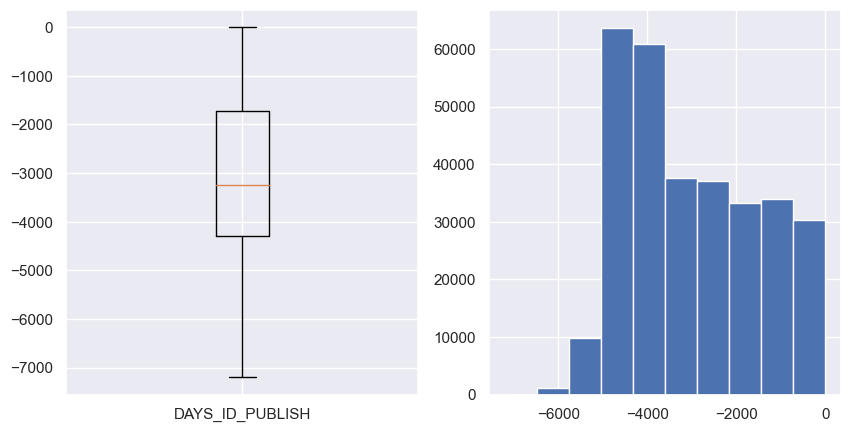

In [42]:
plot_hist_box(numerical_frame, 'DAYS_ID_PUBLISH')

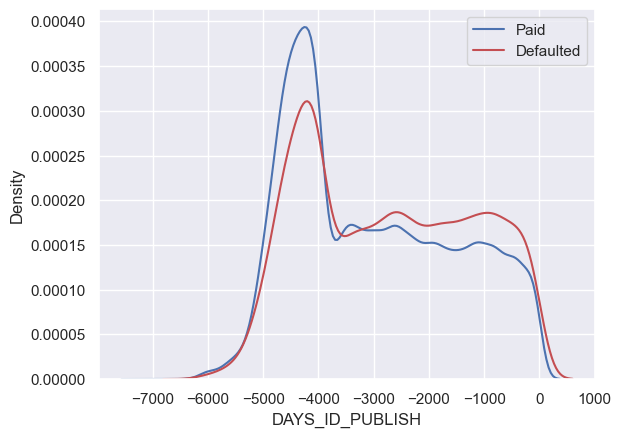

In [43]:

plot_kde_vs_target('DAYS_ID_PUBLISH', numerical_frame)

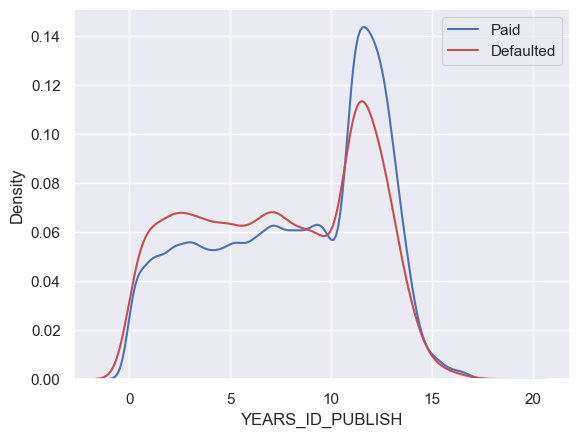

In [44]:
numerical_frame['YEARS_ID_PUBLISH']=numerical_frame['DAYS_ID_PUBLISH']/-365
plot_kde_vs_target('YEARS_ID_PUBLISH', numerical_frame)

(-0.001, 2.192]     10.169541
(2.192, 4.192]       9.734176
(4.192, 6.197]       9.210642
(6.197, 8.0]         8.753588
(8.0, 9.789]         7.963488
(9.789, 11.205]      7.880824
(11.205, 11.978]     6.769168
(11.978, 12.833]     6.095099
(12.833, 19.718]     6.074712
Name: YEARS_ID_PUBLISH_binned, dtype: float64


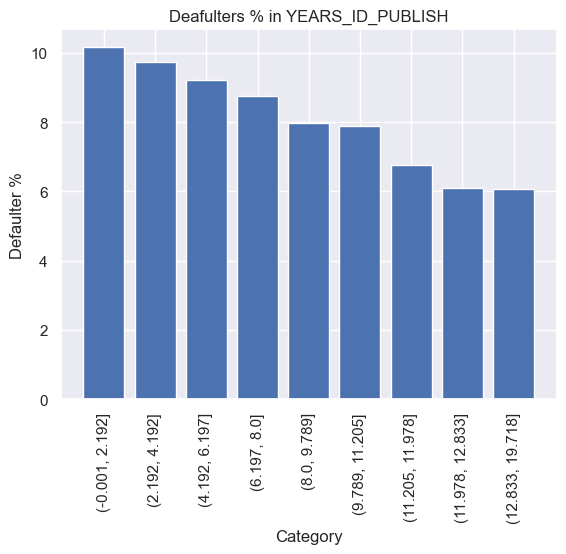

In [45]:
plot_hist_default_pct('YEARS_ID_PUBLISH', numerical_frame, 9)

## DAYS_REGISTRATION

In [46]:
numerical_frame['DAYS_REGISTRATION'].isnull().sum()

0

In [47]:
numerical_frame['DAYS_REGISTRATION'].describe()

count    307511.000000
mean      -4986.120328
std        3522.886321
min      -24672.000000
25%       -7479.500000
50%       -4504.000000
75%       -2010.000000
max           0.000000
Name: DAYS_REGISTRATION, dtype: float64

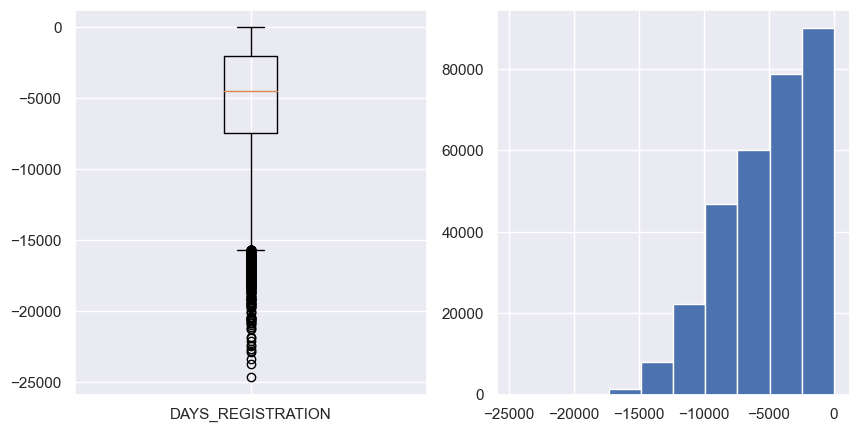

In [48]:
plot_hist_box(numerical_frame, 'DAYS_REGISTRATION')

Number of outliers : 30


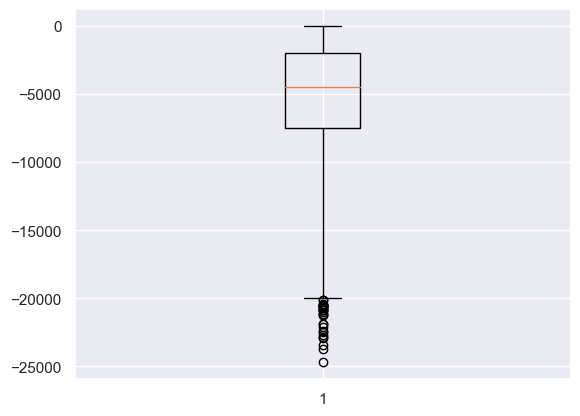

In [62]:
plt.boxplot(numerical_frame['DAYS_REGISTRATION'], whis=2.3);
numerical_frame['YEARS_REGISTRATION']=numerical_frame['DAYS_REGISTRATION']/-365
q1, q3, iqr=calc_iqr('DAYS_REGISTRATION', numerical_frame)
numerical_frame['DAYS_REGISTRATION_outlier']=0
numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']<q1-2.3*iqr, 'DAYS_REGISTRATION_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_REGISTRATION_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_REGISTRATION_outlier']==1).sum()))

In [145]:
# fig, axes=plt.subplots(ncols=2)
# fig.set_size_inches(w=10, h=5)
# plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']<-15500, 'TARGET'], ax=axes[1])
# axes[1].set_title("Defaulters in Outliers");
# plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']>=-15500, 'TARGET'], ax=axes[0])
# axes[0].set_title("Defaulters in Non_Outliers");


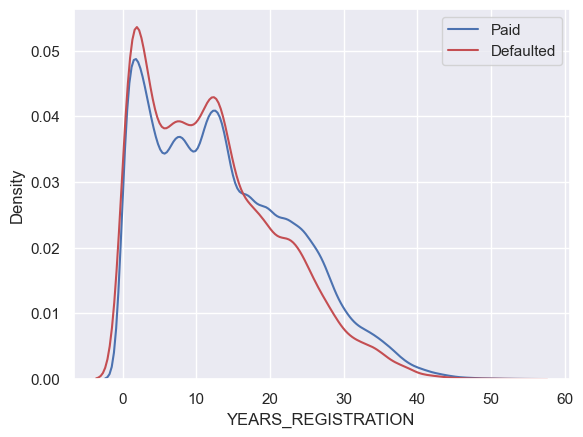

In [63]:
plot_kde_vs_target('YEARS_REGISTRATION', good_frame)

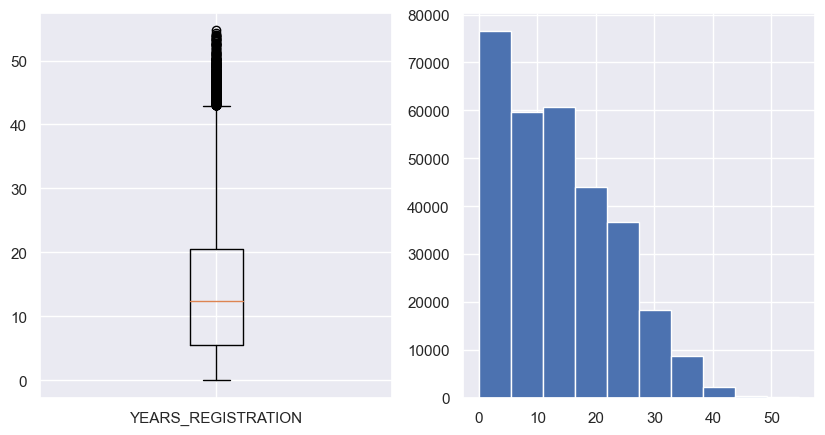

In [64]:
plot_hist_box(good_frame, 'YEARS_REGISTRATION');

(-0.001, 2.107]     9.656947
(2.107, 4.699]      8.869056
(4.699, 7.838]      8.647509
(7.838, 10.978]     8.747329
(10.978, 13.671]    8.634861
(13.671, 17.307]    8.198354
(17.307, 21.655]    7.336066
(21.655, 26.611]    6.896451
(26.611, 54.753]    5.671703
Name: YEARS_REGISTRATION_binned, dtype: float64


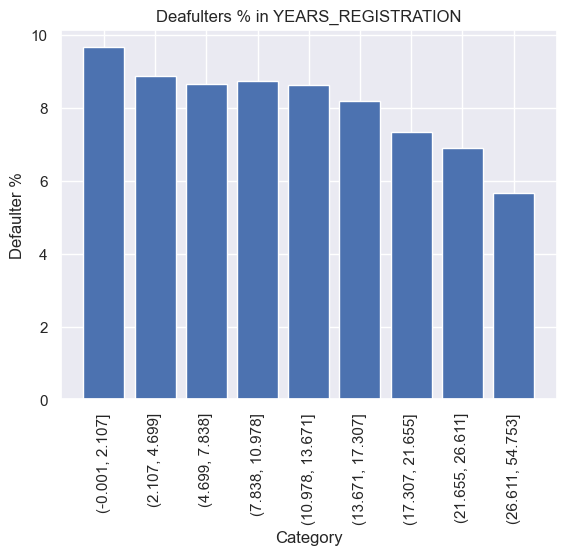

In [65]:
plot_hist_default_pct('YEARS_REGISTRATION', good_frame, 9)

## DAYS_EMPLOYED

In [53]:
numerical_frame['DAYS_EMPLOYED'].isnull().sum()

0

In [54]:
numerical_frame['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

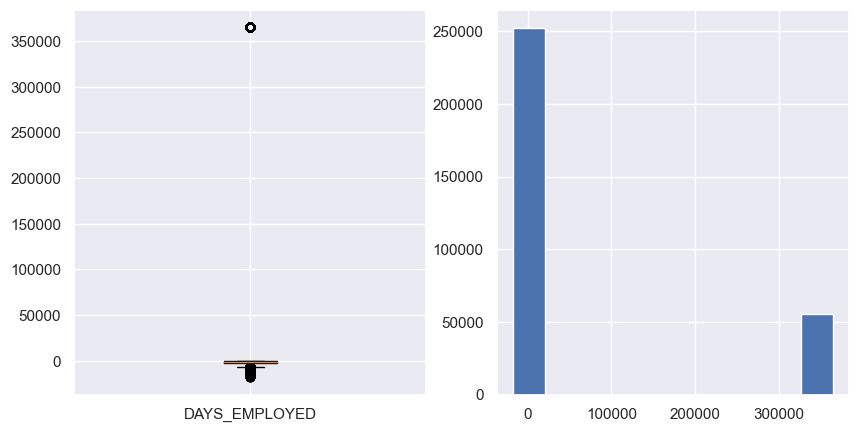

In [55]:
plot_hist_box(numerical_frame, 'DAYS_EMPLOYED')

In [56]:
numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']>0, ['DAYS_EMPLOYED', 'TARGET']].value_counts()

DAYS_EMPLOYED  TARGET
365243         0         52384
               1          2990
dtype: int64

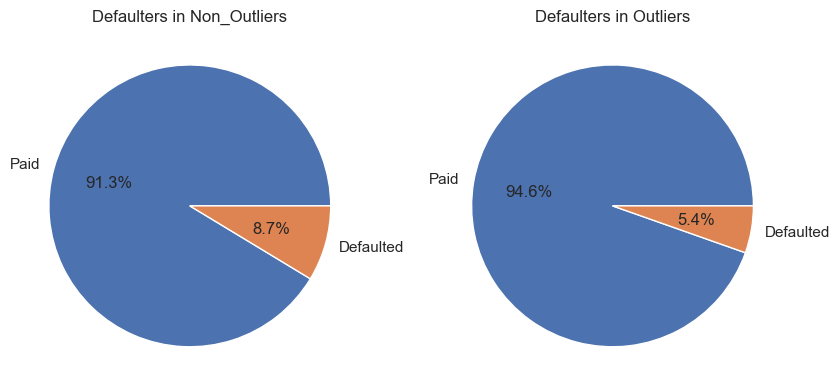

In [57]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']>0, 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in Outliers");
plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']<=0, 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_Outliers");


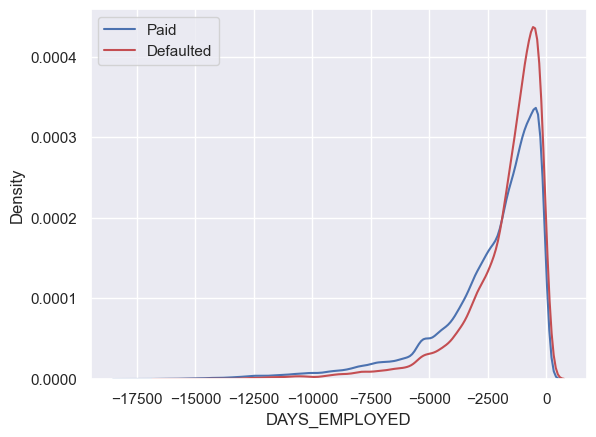

In [58]:
numerical_frame.replace({'DAYS_EMPLOYED': {365243: np.nan}}, inplace=True)
plot_kde_vs_target('DAYS_EMPLOYED', numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']<=0, :])

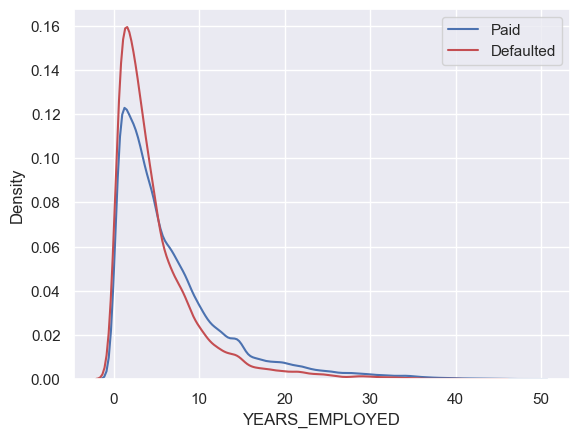

In [59]:
numerical_frame['YEARS_EMPLOYED']=numerical_frame['DAYS_EMPLOYED']/-365
plot_kde_vs_target('YEARS_EMPLOYED', numerical_frame)

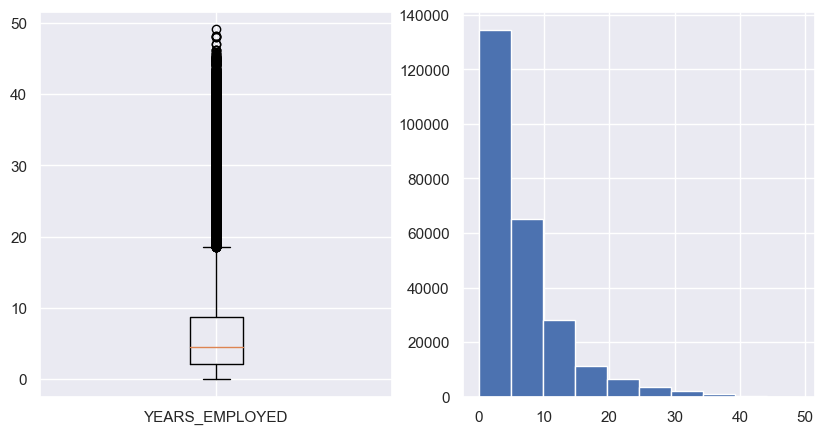

In [60]:
plot_hist_box(numerical_frame, 'YEARS_EMPLOYED')

(-0.001, 1.003]     10.975697
(1.003, 1.879]      11.456996
(1.879, 2.808]      10.972729
(2.808, 3.89]       10.115246
(3.89, 5.208]        9.103871
(5.208, 7.036]       7.757203
(7.036, 9.427]       7.010530
(9.427, 14.008]      5.878993
(14.008, 49.074]     4.663619
Name: YEARS_EMPLOYED_binned, dtype: float64


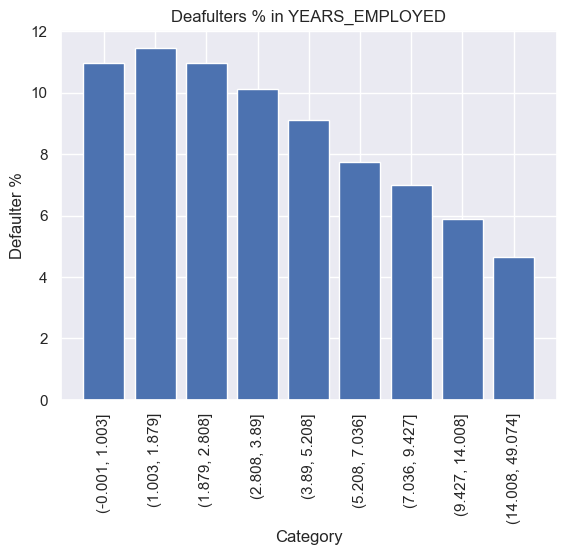

In [61]:
plot_hist_default_pct('YEARS_EMPLOYED', numerical_frame, 9)

#### Looking at outliers

         AMT_CREDIT   YEARS_BIRTH        TARGET
count  5.537400e+04  55374.000000  55374.000000
mean   5.426899e+05     59.753450      0.053996
std    3.784991e+05      5.501600      0.226013
min    4.500000e+04     21.071233      0.000000
25%    2.547000e+05     57.093151      0.000000
50%    4.578345e+05     60.413699      0.000000
75%    7.551900e+05     63.487671      0.000000
max    3.312162e+06     69.120548      1.000000


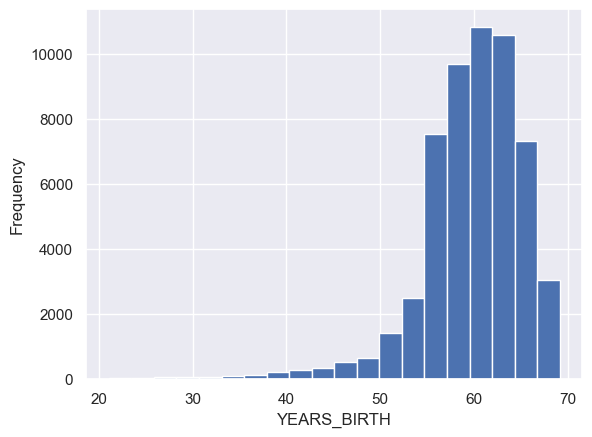

In [62]:
outlier_frame=numerical_frame.loc[numerical_frame['YEARS_EMPLOYED'].isnull(), ['AMT_CREDIT', 'YEARS_BIRTH', 'TARGET']]
print(outlier_frame.describe())
ax=outlier_frame['YEARS_BIRTH'].plot.hist(bins=20)
ax.set_xlabel('YEARS_BIRTH');

In [63]:
mean=numerical_frame.loc[(numerical_frame['YEARS_EMPLOYED']>7.5) & (numerical_frame['YEARS_EMPLOYED']<50), 'YEARS_EMPLOYED'].median()
mean

11.791780821917808

(-0.001, 1.0]       10.971339
(1.0, 1.874]        11.469367
(1.874, 2.803]      10.960913
(2.803, 3.879]      10.142750
(3.879, 5.192]       9.088960
(5.192, 7.011]       7.802434
(7.011, 9.375]       7.027530
(9.375, 11.792]      5.548320
(11.792, 14.022]     5.619109
(14.022, 49.074]     4.661729
Name: YEARS_EMPLOYED_binned, dtype: float64


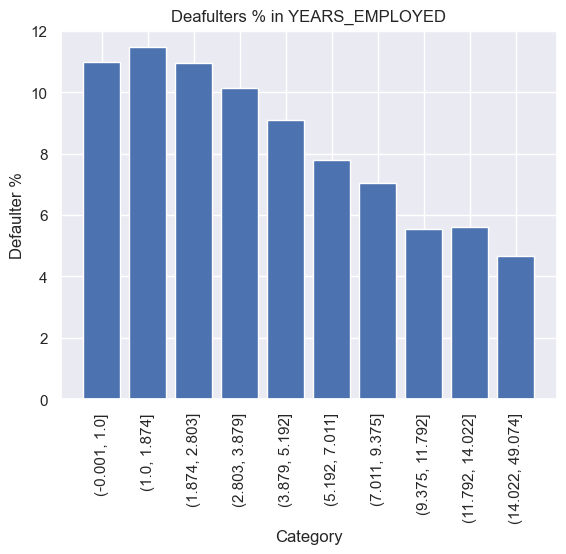

In [64]:
numerical_frame.loc[numerical_frame['YEARS_EMPLOYED'].isnull(), 'YEARS_EMPLOYED']=mean
plot_hist_default_pct('YEARS_EMPLOYED', numerical_frame, 11)

## DAYS_LAST_PHONE_CHANGE

In [65]:
numerical_frame['DAYS_LAST_PHONE_CHANGE'].isnull().sum()

1

In [66]:
numerical_frame['DAYS_LAST_PHONE_CHANGE'].describe()

count    307510.000000
mean       -962.858788
std         826.808487
min       -4292.000000
25%       -1570.000000
50%        -757.000000
75%        -274.000000
max           0.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64

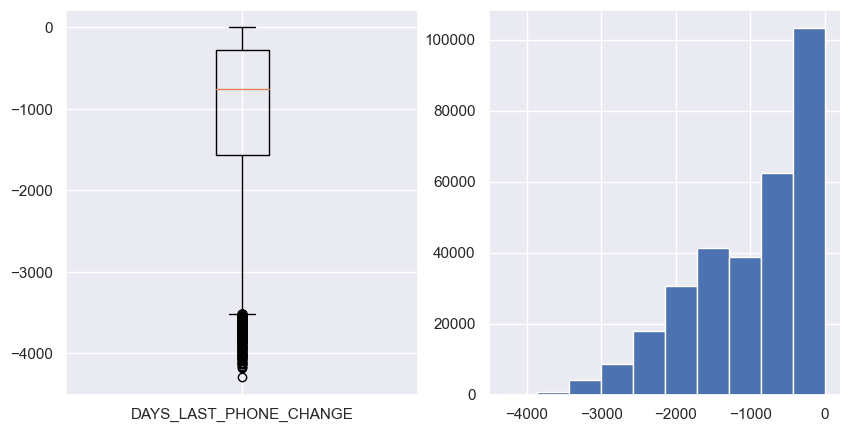

In [67]:
plot_hist_box(numerical_frame, 'DAYS_LAST_PHONE_CHANGE')

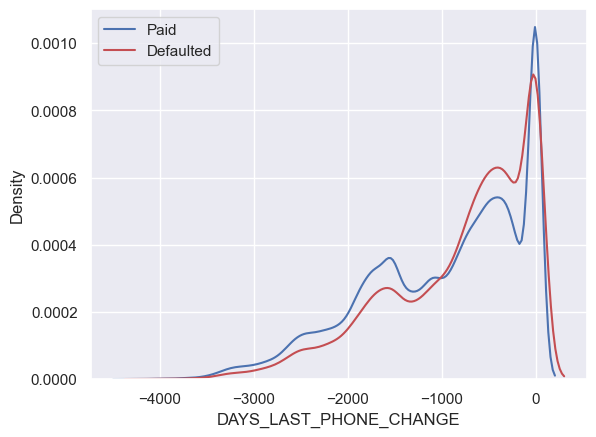

In [68]:
plot_kde_vs_target('DAYS_LAST_PHONE_CHANGE', numerical_frame)

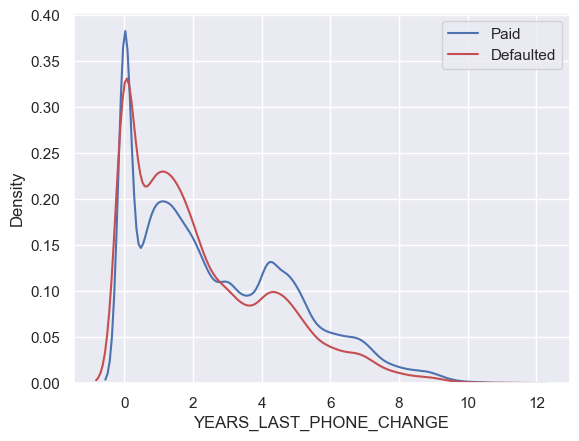

In [69]:
numerical_frame['YEARS_LAST_PHONE_CHANGE']=numerical_frame['DAYS_LAST_PHONE_CHANGE']/-365
plot_kde_vs_target('YEARS_LAST_PHONE_CHANGE', numerical_frame)

(-0.001, 0.592]    9.447335
(0.592, 1.164]     9.585872
(1.164, 1.74]      9.466710
(1.74, 2.488]      8.822155
(2.488, 3.548]     7.624711
(3.548, 4.523]     6.531868
(4.523, 5.712]     6.268840
(5.712, 11.759]    5.456674
Name: YEARS_LAST_PHONE_CHANGE_binned, dtype: float64


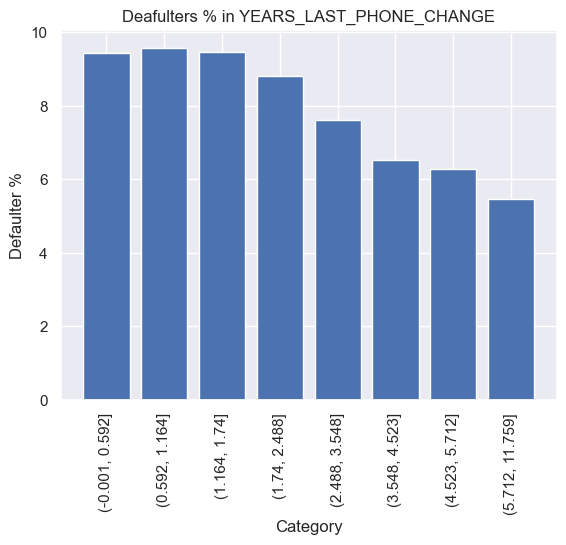

In [70]:
plot_hist_default_pct('YEARS_LAST_PHONE_CHANGE', numerical_frame, 9)

#### Imputing NAN values

In [71]:
numerical_frame.loc[numerical_frame['YEARS_LAST_PHONE_CHANGE'].isnull(), 'TARGET']

15709    0
Name: TARGET, dtype: int64

In [72]:
median=numerical_frame.loc[numerical_frame['TARGET']==0, 'YEARS_LAST_PHONE_CHANGE'].median()
median

2.126027397260274

In [73]:
numerical_frame.loc[numerical_frame['YEARS_LAST_PHONE_CHANGE'].isnull(), 'YEARS_LAST_PHONE_CHANGE']=median

## EXT_SOURCE_1

In [74]:
numerical_frame['EXT_SOURCE_1'].isnull().sum()

173378

In [75]:
numerical_frame['EXT_SOURCE_1'].describe()

count    134133.000000
mean          0.502130
std           0.211062
min           0.014568
25%           0.334007
50%           0.505998
75%           0.675053
max           0.962693
Name: EXT_SOURCE_1, dtype: float64

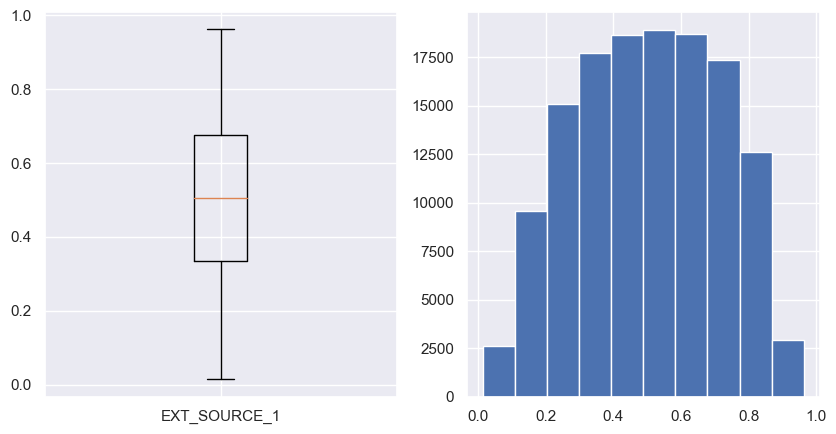

In [76]:
plot_hist_box(numerical_frame, 'EXT_SOURCE_1')

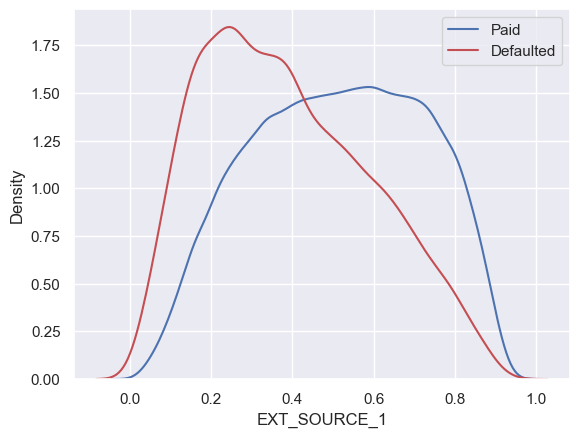

In [77]:
plot_kde_vs_target('EXT_SOURCE_1', numerical_frame)

(0.013600000000000001, 0.223]    16.968599
(0.223, 0.313]                   11.225174
(0.313, 0.392]                    9.078709
(0.392, 0.468]                    7.440955
(0.468, 0.544]                    6.401396
(0.544, 0.618]                    5.414654
(0.618, 0.694]                    4.737301
(0.694, 0.777]                    3.502415
(0.777, 0.963]                    2.690553
Name: EXT_SOURCE_1_binned, dtype: float64


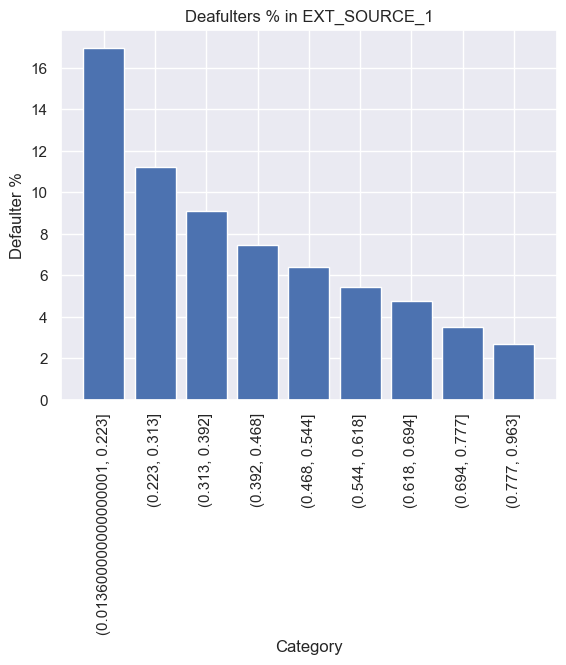

In [78]:
plot_hist_default_pct('EXT_SOURCE_1', numerical_frame, 9)

#### Imputing NAN values

In [79]:
numerical_frame.loc[numerical_frame['EXT_SOURCE_1'].isnull(), 'TARGET'].value_counts()

0    158607
1     14771
Name: TARGET, dtype: int64

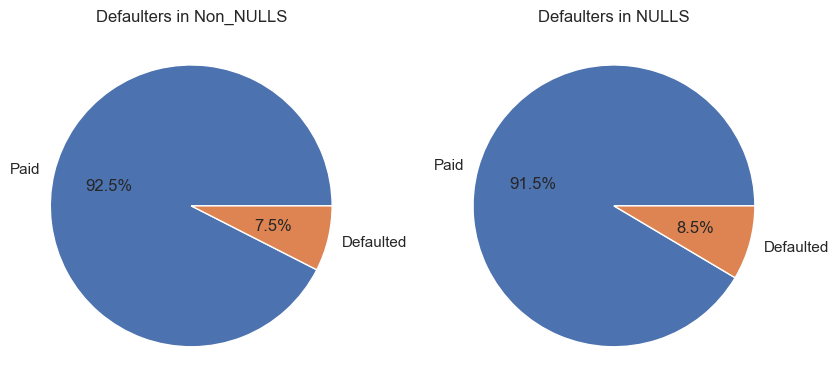

In [80]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_1'].isnull(), 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in NULLS");
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_1'].notnull(), 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_NULLS");


## EXT_SOURCE_2

In [81]:
numerical_frame['EXT_SOURCE_2'].isnull().sum()

660

In [82]:
numerical_frame['EXT_SOURCE_2'].describe()

count    3.068510e+05
mean     5.143927e-01
std      1.910602e-01
min      8.173617e-08
25%      3.924574e-01
50%      5.659614e-01
75%      6.636171e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64

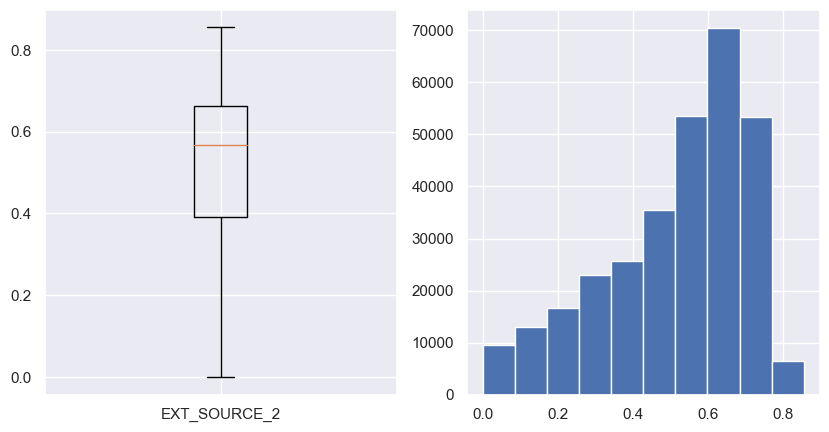

In [83]:
plot_hist_box(numerical_frame, 'EXT_SOURCE_2')

Median of EXT_SOURCE_3 with target=0 : 0.546023
Median of EXT_SOURCE_3 with target=1 : 0.379100


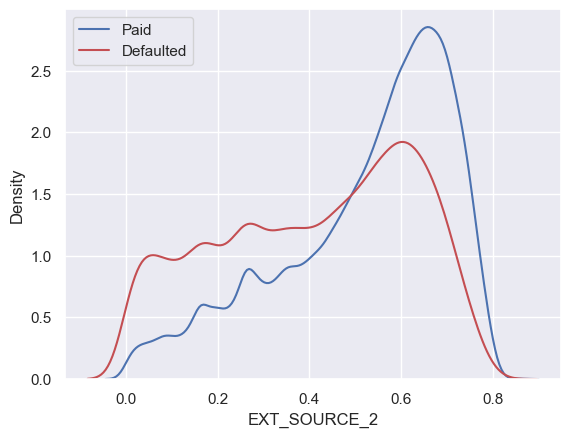

In [84]:
plot_kde_vs_target('EXT_SOURCE_2', numerical_frame)
median_vs_target('EXT_SOURCE_3', numerical_frame)

(-0.0009999183, 0.234]    17.855991
(0.234, 0.362]            11.614947
(0.362, 0.467]             9.555093
(0.467, 0.538]             7.866948
(0.538, 0.59]              7.047541
(0.59, 0.634]              6.168603
(0.634, 0.674]             5.167913
(0.674, 0.717]             4.338007
(0.717, 0.855]             3.044435
Name: EXT_SOURCE_2_binned, dtype: float64


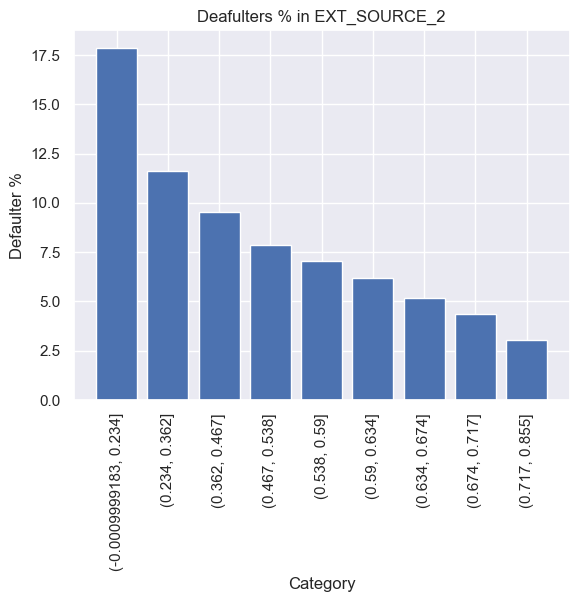

In [85]:
plot_hist_default_pct('EXT_SOURCE_2', numerical_frame, 9)

#### Imputing NAN values

In [86]:
numerical_frame.loc[numerical_frame['EXT_SOURCE_2'].isnull(), 'TARGET'].value_counts()

0    608
1     52
Name: TARGET, dtype: int64

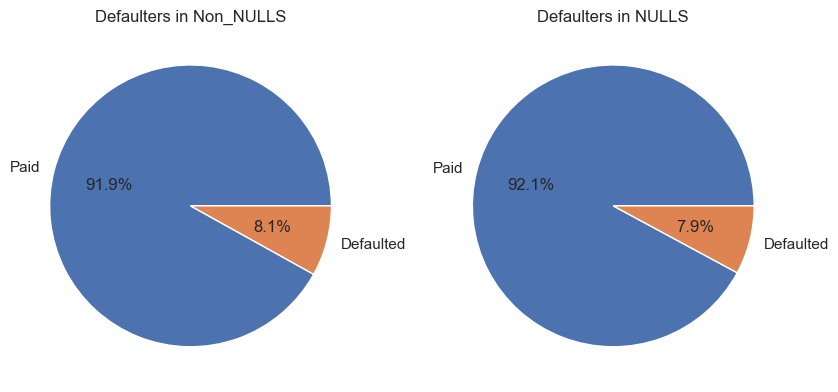

In [87]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_2'].isnull(), 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in NULLS");
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_2'].notnull(), 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_NULLS");


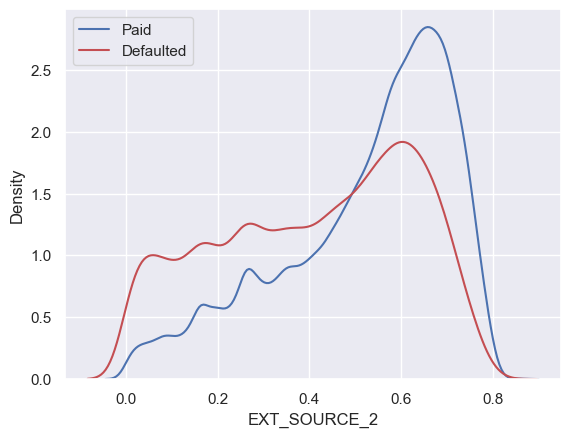

In [88]:
def impute_median_vs_target(feature, data):
    median_0=data.loc[data['TARGET']==0, feature].median()
    median_1=data.loc[data['TARGET']==1, feature].median()
    apply_dict={0: median_0, 1: median_1}
    return data.loc[data[feature].isnull(), 'TARGET'].apply(lambda x: apply_dict[x])

numerical_frame.loc[numerical_frame['EXT_SOURCE_2'].isnull(), 'EXT_SOURCE_2']=impute_median_vs_target('EXT_SOURCE_2', numerical_frame)

plot_kde_vs_target('EXT_SOURCE_2', numerical_frame)

## EXT_SOURCE_3

In [91]:
numerical_frame['EXT_SOURCE_3'].isnull().sum()

60965

In [92]:
numerical_frame['EXT_SOURCE_3'].describe()

count    246546.000000
mean          0.510853
std           0.194844
min           0.000527
25%           0.370650
50%           0.535276
75%           0.669057
max           0.896010
Name: EXT_SOURCE_3, dtype: float64

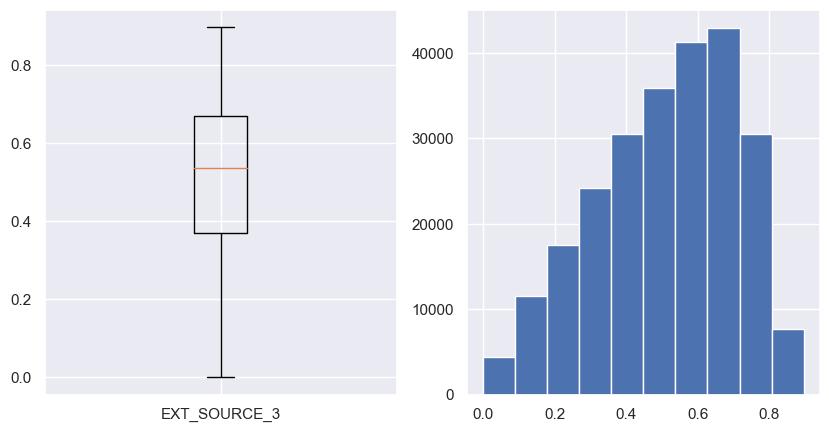

In [93]:
plot_hist_box(numerical_frame, 'EXT_SOURCE_3')

Median of EXT_SOURCE_3 with target=0 : 0.546023
Median of EXT_SOURCE_3 with target=1 : 0.379100


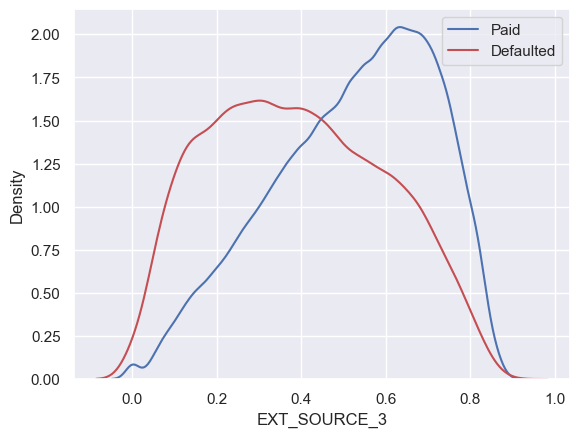

In [92]:
plot_kde_vs_target('EXT_SOURCE_3', numerical_frame)
median_vs_target('EXT_SOURCE_3', numerical_frame)

(-0.000473, 0.241]    19.504925
(0.241, 0.349]        11.999276
(0.349, 0.431]         9.081228
(0.431, 0.503]         7.340862
(0.503, 0.566]         5.775487
(0.566, 0.626]         4.846578
(0.626, 0.682]         4.322928
(0.682, 0.744]         3.695388
(0.744, 0.896]         3.219559
Name: EXT_SOURCE_3_binned, dtype: float64


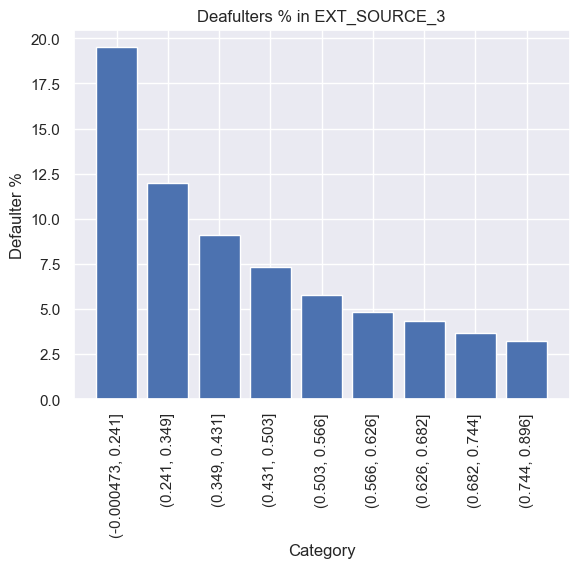

In [101]:
plot_hist_default_pct('EXT_SOURCE_3', numerical_frame, 9)

#### Imputing NAN values

In [97]:
numerical_frame.loc[numerical_frame['EXT_SOURCE_3'].isnull(), 'TARGET'].value_counts()

0    55288
1     5677
Name: TARGET, dtype: int64

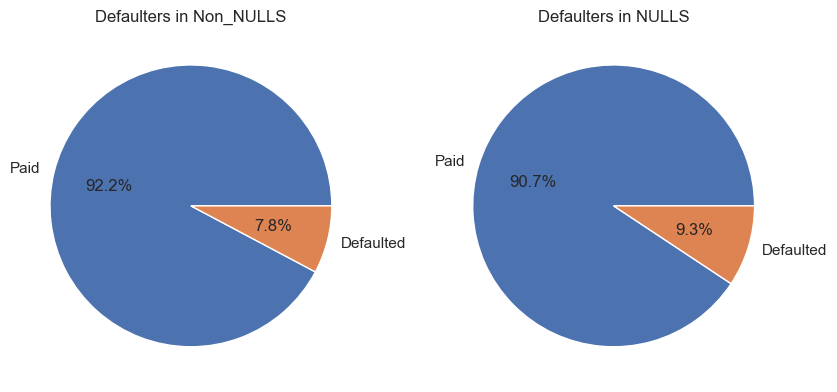

In [98]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_3'].isnull(), 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in NULLS");
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_3'].notnull(), 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_NULLS");


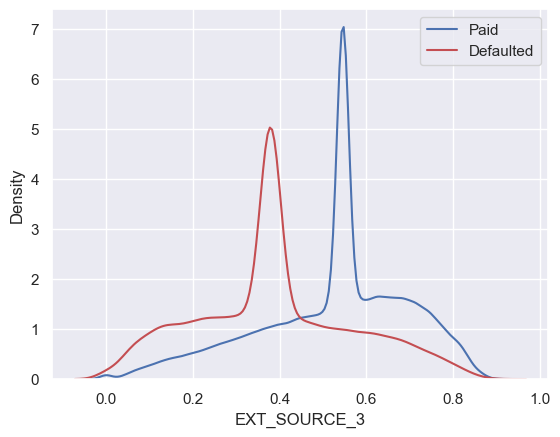

In [89]:
df=numerical_frame.copy()
df.loc[df['EXT_SOURCE_3'].isnull(), 'EXT_SOURCE_3']=impute_median_vs_target('EXT_SOURCE_3', df)

plot_kde_vs_target('EXT_SOURCE_3', df)